In [1]:
import time
import random
import os
import wfdb
import idx2numpy
import sys
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy.io as sio

from pathlib import Path
from skimage import draw
from datetime import datetime
from math import log10, sqrt
from screenlib import util, model, optimizer, screening
from matplotlib import style
from matplotlib.ticker import LogLocator, FixedLocator, ScalarFormatter
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split

In [2]:
sys.path.append(str(Path().resolve().parent))

import source.optimizer as optimizer
import source.model as model

In [ ]:
plt.style.use('default')
plt.rcParams.update({'font.size': 16})
plt.rcParams.update({'font.family': 'serif'})

x_ticks = [0.01,0.05,0.1,0.5,1.0]

In [3]:
np.random.seed(5)
random.seed(5)

# Loading dataset

In [5]:
dim_atom  = 100
num_atoms = 20000
card      = 10
mean      = 0
sigma     = 1.6e-1

In [6]:
mat_dict = sio.loadmat('../datasets/dictionary-shapes/basic_shapes.mat')

In [7]:
X = mat_dict['X']

u_teo = np.zeros([num_atoms,1], dtype=float)

indices = np.random.choice(num_atoms, card, replace=False)
values = np.abs(np.random.rand(card, 1))
values = values/np.sum(values)

u_teo[indices] = values

y_teo = np.matmul(X, u_teo)

y = y_teo + np.random.normal(0, sigma, (len(y_teo),1))

# Experiment

In [8]:
num_loops = 10
max_iter  = 250
tol       = 1e-16
eps       = np.finfo(float).eps
n_bins    = 8
n_points  = 20
mag_ord_start = -2
mag_ord_end = 0

In [9]:
lmb_r = np.float32(np.logspace(mag_ord_start, mag_ord_end, num=n_points, endpoint=False))

In [10]:
lmb_max = np.linalg.norm(np.matmul(X.T, y), np.inf)

In [11]:
lmb_vec = lmb_r*lmb_max

In [12]:
params_dict    = {}
functions_dict = {}
screening_dict = {}

In [13]:
time_min_vec  = []
time_mean_vec = []
time_max_vec  = []
psnr_vec = []
card_vec      = []
true_card_vec = []
supp_mat = []

In [14]:
params_dict['ss']       = 0
params_dict['alpha']    = 2.5e-7
params_dict['max_iter'] = max_iter
params_dict['tol']      = tol
params_dict['c']        = 1
params_dict['k_dyn']    = 0
params_dict['k_skip']   = 5
params_dict['stop_crit'] = 0

In [15]:
functions_dict['f']       = model.lsqrloss
functions_dict['g']       = model.l1norm
functions_dict['df_du']   = model.grad_lsqrloss
functions_dict['prox_g']  = model.prox_l1norm
functions_dict['fc']      = model.lsqrloss_conj
functions_dict['L']       = 1
functions_dict['lmb_max'] = lmb_max

In [16]:
u_0 = np.zeros([num_atoms,1], dtype=float)

In [17]:
idx_global = np.arange(u_0.shape[0])

In [18]:
alphas_dict = {}

alphas_dict['alpha_0'] = 0.9
alphas_dict['alpha_1'] = 0.9
alphas_dict['alpha_2'] = 0.5
alphas_dict['alpha_3'] = 0.5
alphas_dict['alpha_4'] = 0.5

alphas_dict['skew_lim'] = 0.25

## Vanilla

Elapsed time: 19.78 seconds


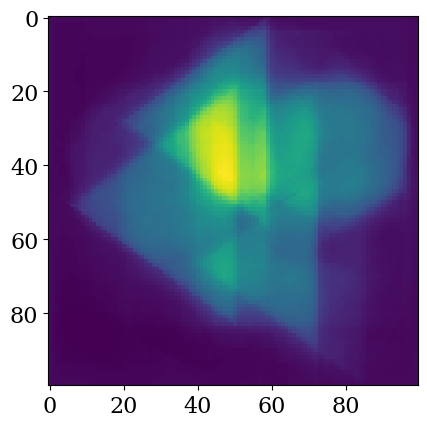

Elapsed time: 19.87 seconds


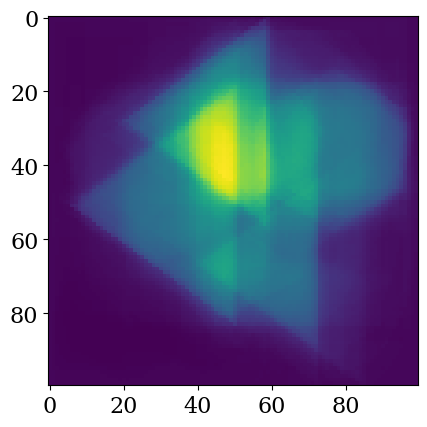

Elapsed time: 18.97 seconds


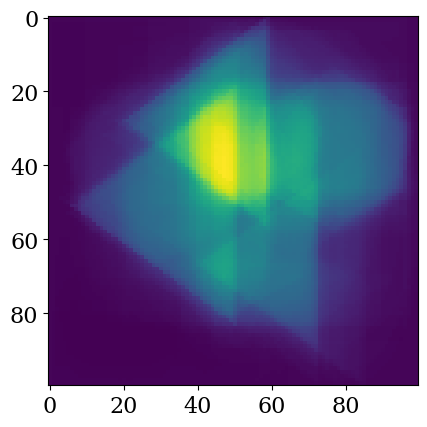

Elapsed time: 19.17 seconds


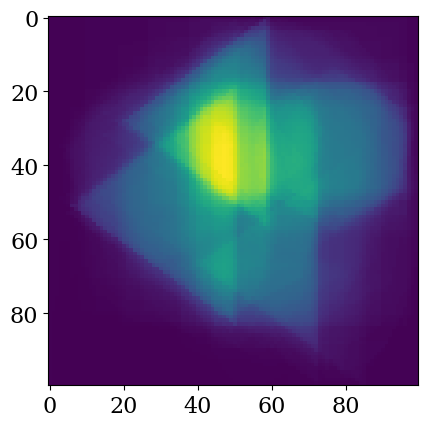

Elapsed time: 19.00 seconds


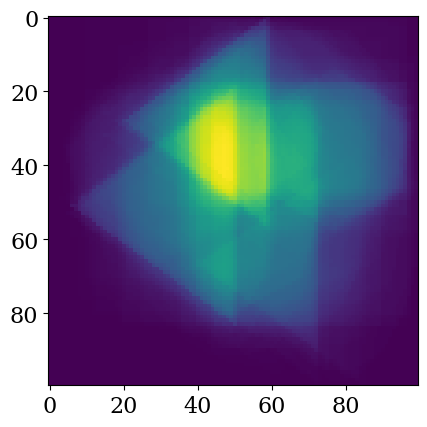

Elapsed time: 19.04 seconds


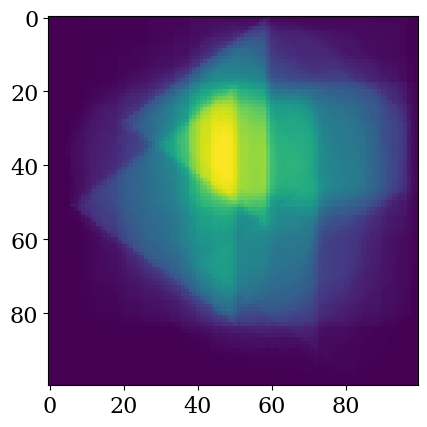

Elapsed time: 19.09 seconds


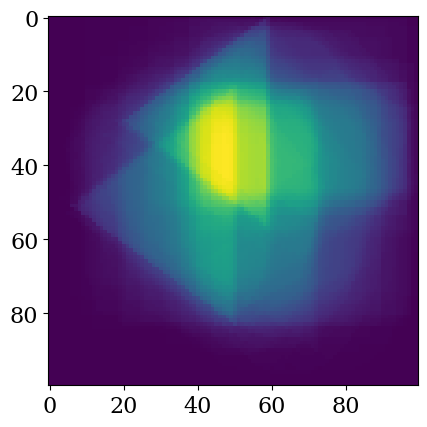

Elapsed time: 18.96 seconds


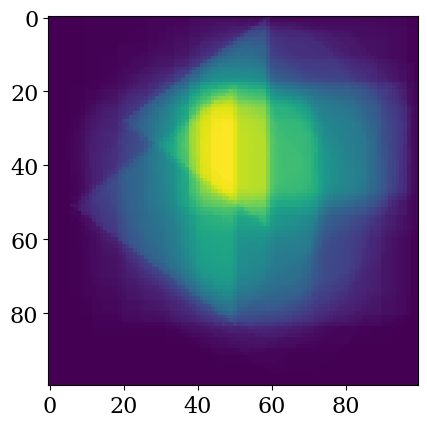

Elapsed time: 18.93 seconds


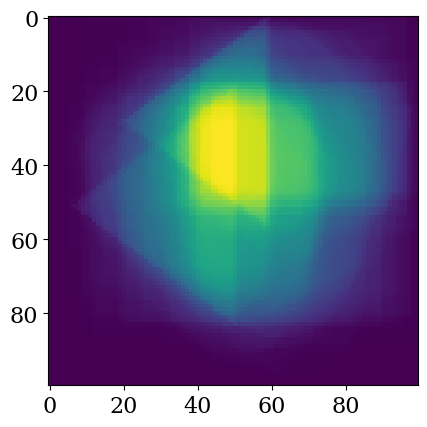

Elapsed time: 19.12 seconds


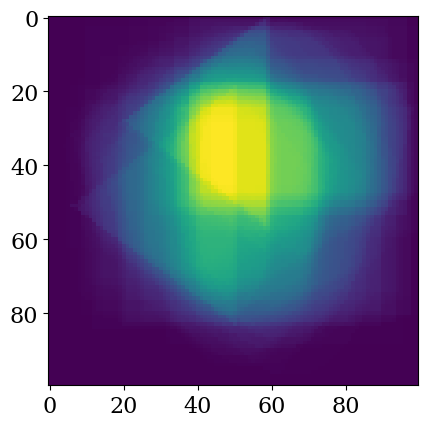

Elapsed time: 18.98 seconds


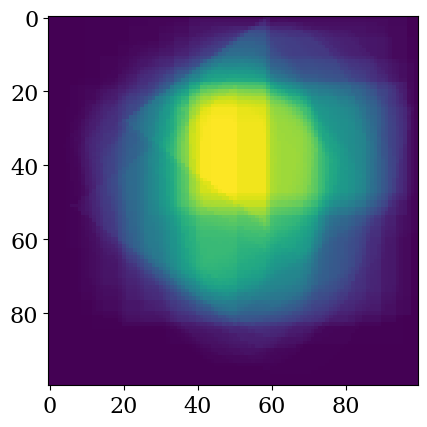

Elapsed time: 19.52 seconds


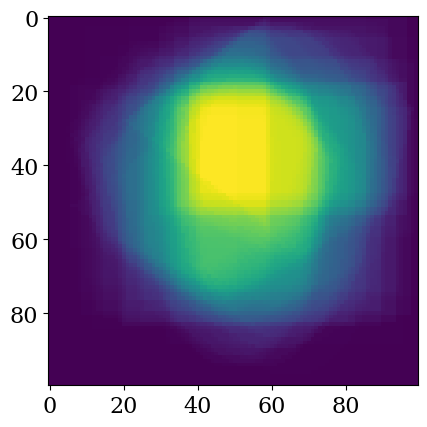

Elapsed time: 20.18 seconds


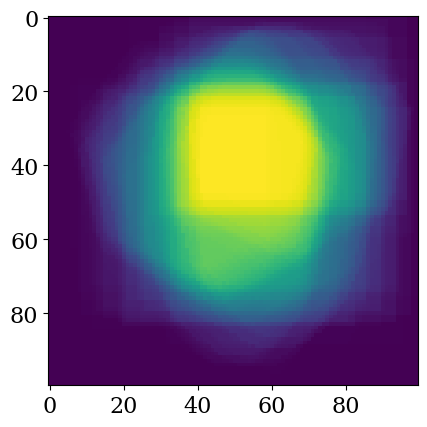

Elapsed time: 20.13 seconds


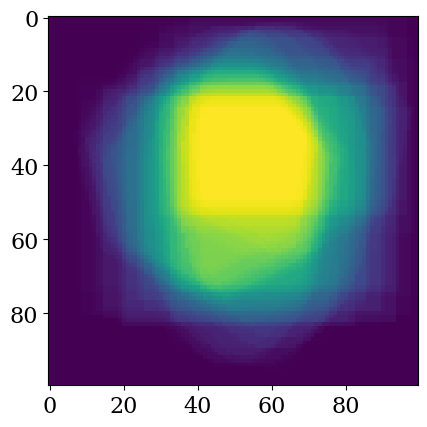

Elapsed time: 20.00 seconds


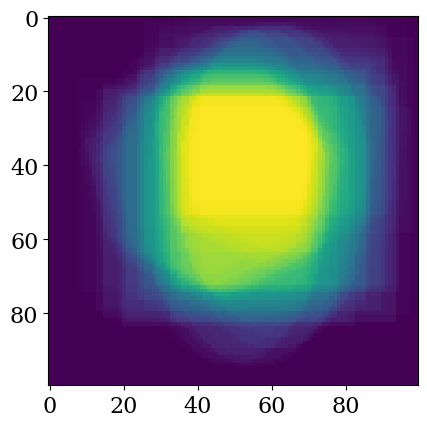

Elapsed time: 20.20 seconds


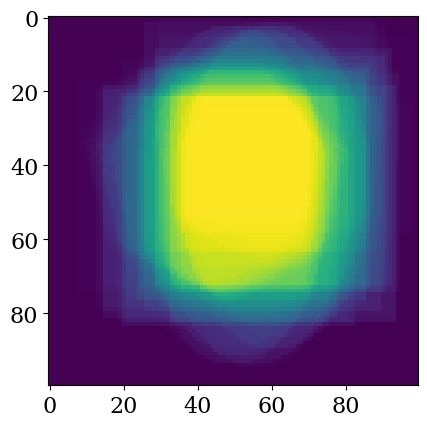

Elapsed time: 20.14 seconds


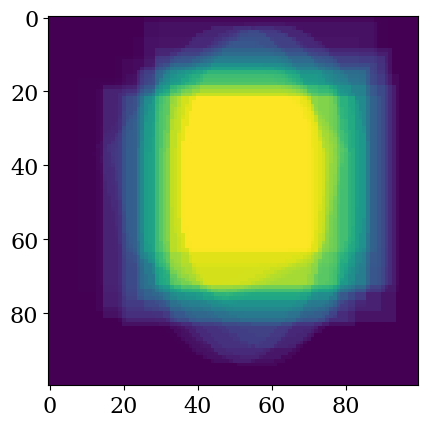

Elapsed time: 20.08 seconds


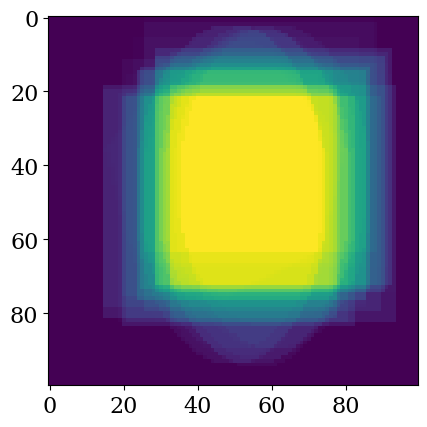

Elapsed time: 20.20 seconds


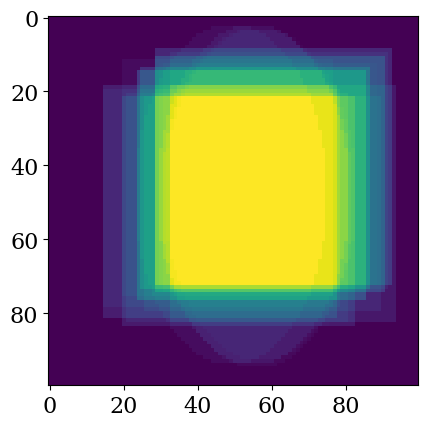

Elapsed time: 19.98 seconds


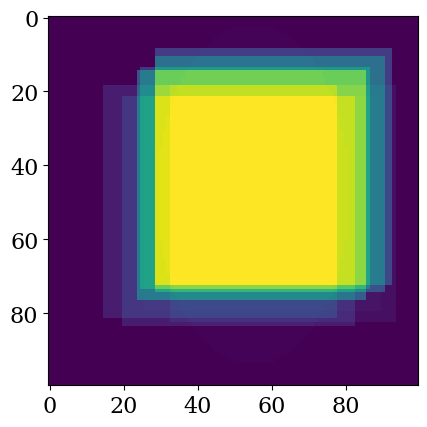

In [19]:
params_dict['k_screening'] = 0

screening_dict['mode'] = 0
screening_dict['n_bins'] = n_bins
screening_dict['thresholding'] = 0

for lmb in lmb_vec:

  time_proc = np.zeros(num_loops, dtype=int)

  for k in range(num_loops):
    t_start = datetime.now()
    u_opt, _, meas, fun_costs = optimizer.apg_opt(y, X, lmb, u_0, params_dict, functions_dict, screening_dict, alphas_dict)
    t_end = datetime.now()
    time_delta = t_end - t_start
    time_proc[k] = time_delta.seconds*1e+6 + time_delta.microseconds

  time_min  = np.min(time_proc)*1e-6
  time_mean = np.mean(time_proc)*1e-6
  time_max  = np.max(time_proc)*1e-6

  time_min_vec.append(time_min)
  time_mean_vec.append(time_mean)
  time_max_vec.append(time_max)

  print("Elapsed time:", "%.2f" % time_mean, "seconds")

  idx_set = idx_global[np.sum(u_opt**2, axis=1)**0.5 > 0]

  supp_mat.append(idx_set)
  card_vec.append(len(idx_set)/u_0.shape[0])

  y_pred = np.matmul(X, u_opt)
  psnr_val = util.compute_psnr(y_pred, y_teo)
  psnr_vec.append(psnr_val)

# Screening

In [20]:
screening_dict['thresholding'] = 0
params_dict['k_screening'] = 1

## Screening: Static gap-safe ball

Elapsed time: 27.30 seconds


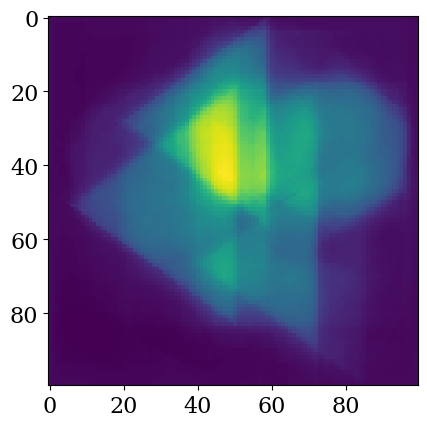

Elapsed time: 27.33 seconds


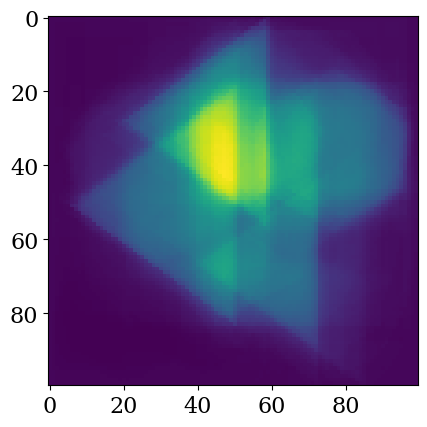

Elapsed time: 24.20 seconds


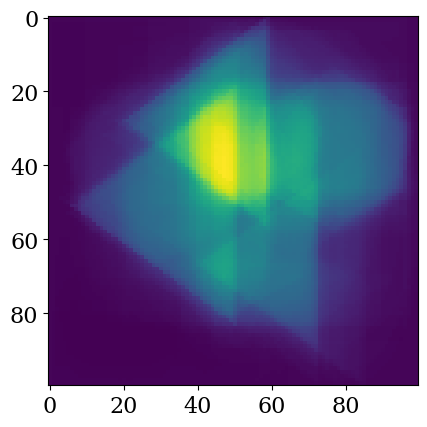

Elapsed time: 24.04 seconds


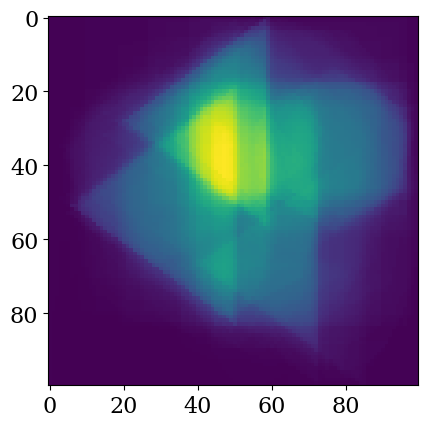

Elapsed time: 23.44 seconds


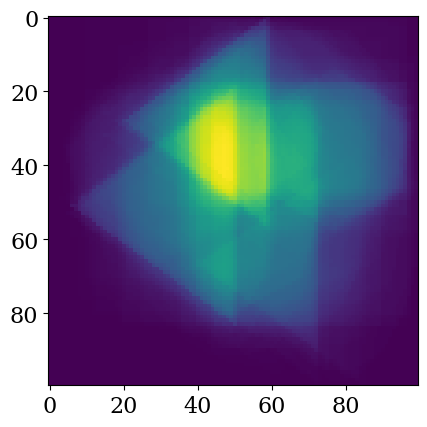

Elapsed time: 23.46 seconds


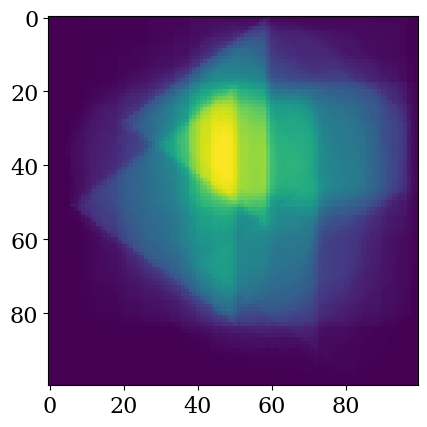

Elapsed time: 23.47 seconds


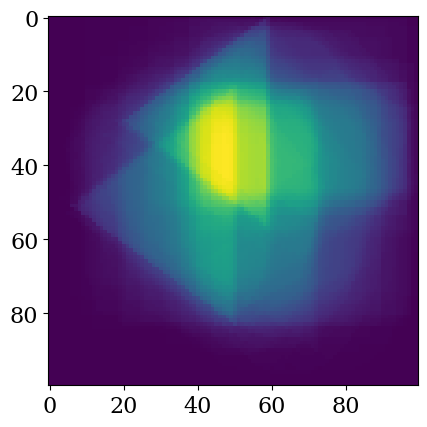

Elapsed time: 23.29 seconds


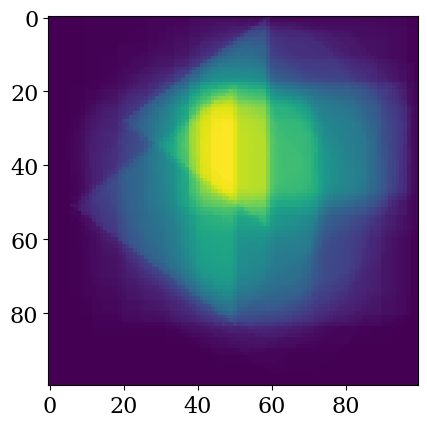

Elapsed time: 23.41 seconds


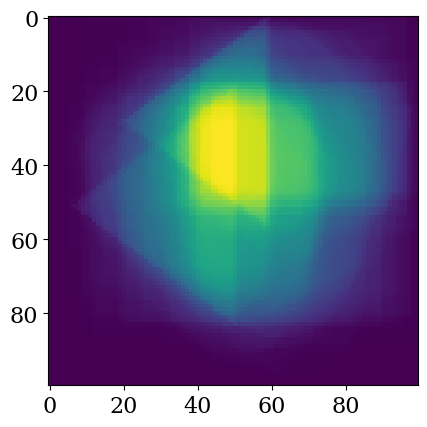

Elapsed time: 23.42 seconds


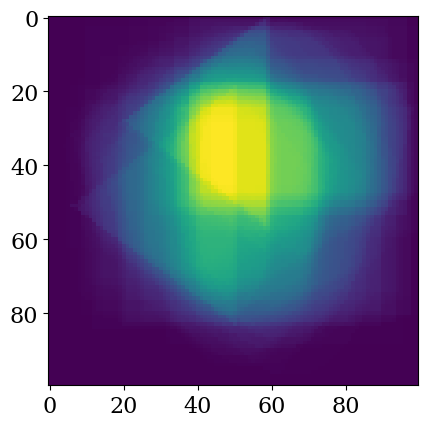

Elapsed time: 23.50 seconds


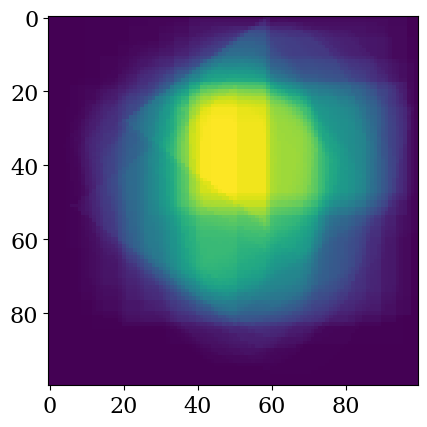

Elapsed time: 24.07 seconds


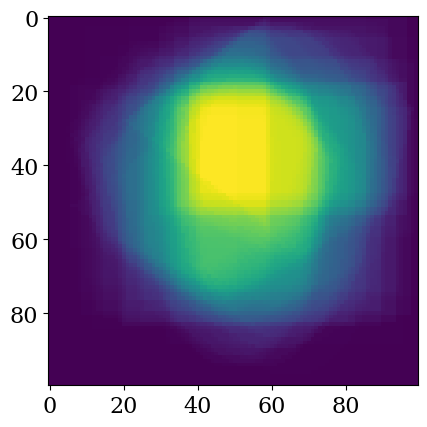

Elapsed time: 24.29 seconds


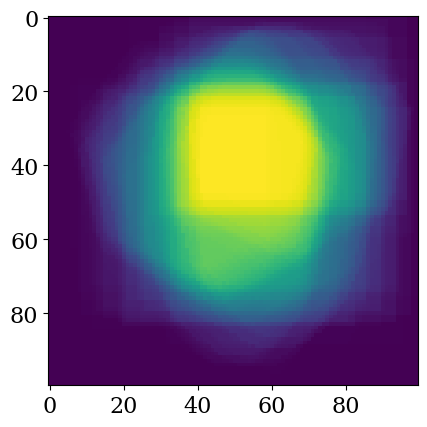

Elapsed time: 23.98 seconds


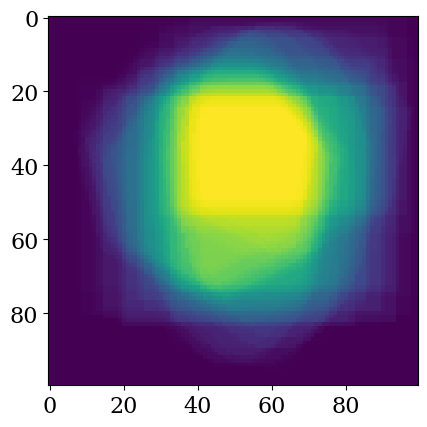

Elapsed time: 23.70 seconds


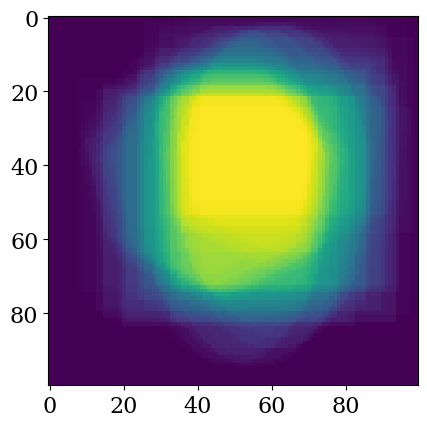

Elapsed time: 23.30 seconds


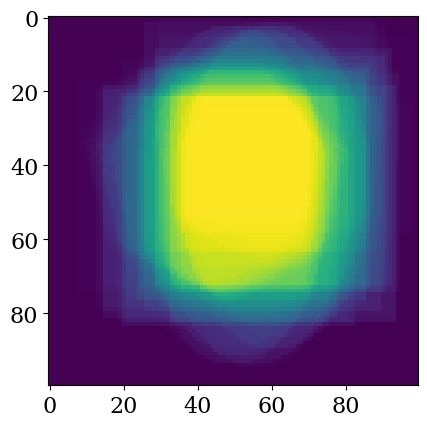

Elapsed time: 21.88 seconds


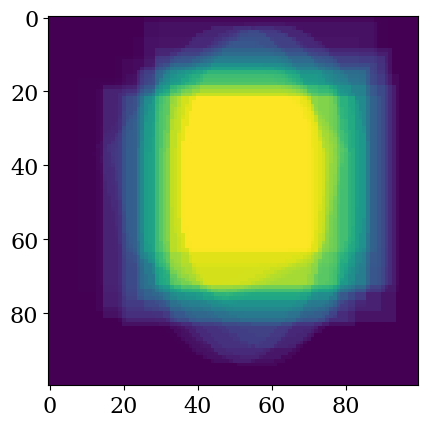

Elapsed time: 17.29 seconds


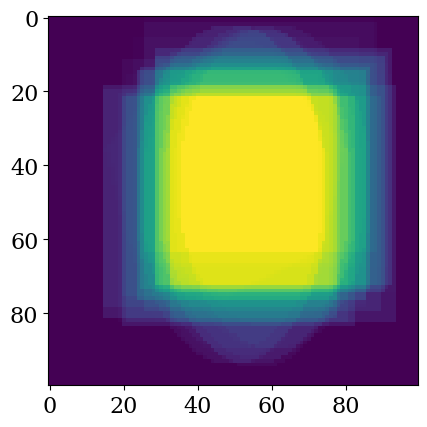

Elapsed time: 10.89 seconds


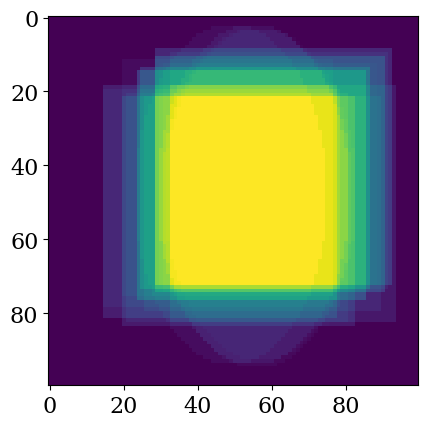

Elapsed time: 6.32 seconds


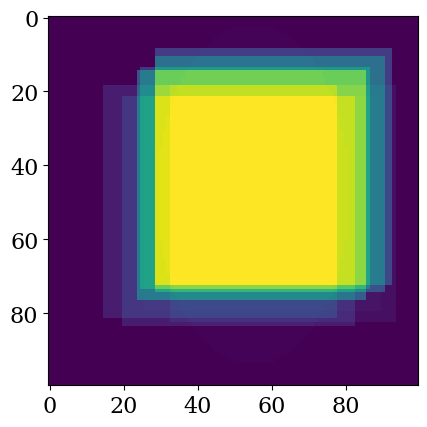

In [21]:
screening_dict['mode'] = 0
screening_dict['n_bins'] = n_bins

for lmb in lmb_vec:

  time_proc = np.zeros(num_loops, dtype=int)

  for k in range(num_loops):
    t_start = datetime.now()
    u_opt, idx_set, meas, fun_costs = optimizer.apg_opt(y, X, lmb, u_0, params_dict, functions_dict, screening_dict, alphas_dict)
    t_end = datetime.now()
    time_delta = t_end - t_start
    time_proc[k] = time_delta.seconds*1e+6 + time_delta.microseconds

  time_min  = np.min(time_proc)*1e-6
  time_mean = np.mean(time_proc)*1e-6
  time_max  = np.max(time_proc)*1e-6

  time_min_vec.append(time_min)
  time_mean_vec.append(time_mean)
  time_max_vec.append(time_max)

  print("Elapsed time:", "%.2f" % time_mean, "seconds")

  supp_mat.append(idx_set)
  card_vec.append(len(idx_set)/u_0.shape[0])

  y_pred = np.matmul(X, u_opt)
  psnr_val = util.compute_psnr(y_pred, y_teo)
  psnr_vec.append(psnr_val)

## Screening: Static strong rules

Elapsed time: 24.03 seconds


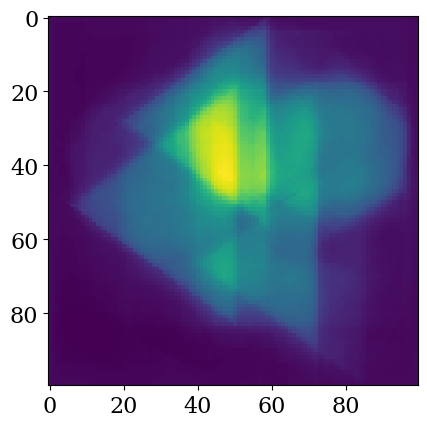

Elapsed time: 24.04 seconds


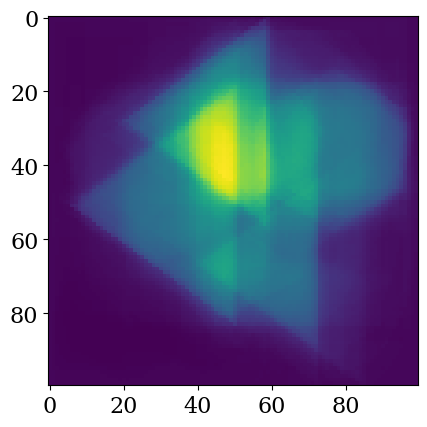

Elapsed time: 24.14 seconds


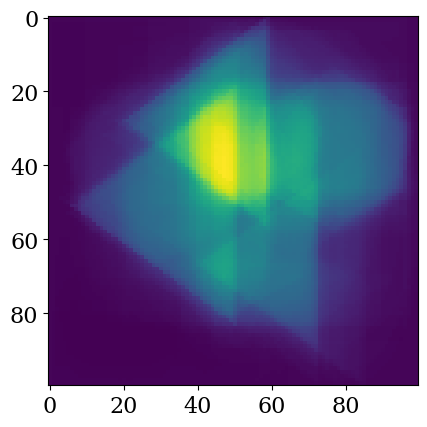

Elapsed time: 23.97 seconds


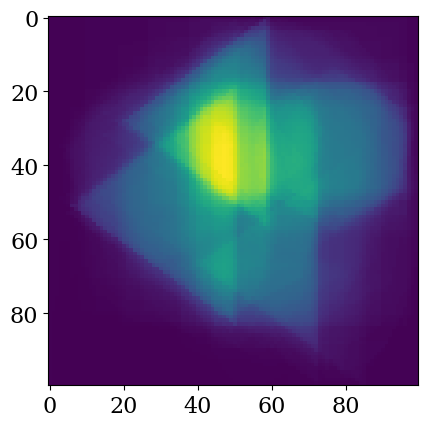

Elapsed time: 24.03 seconds


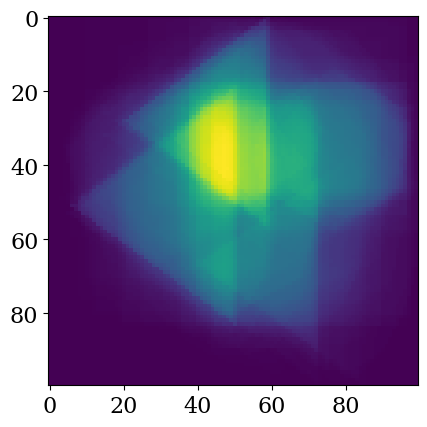

Elapsed time: 24.04 seconds


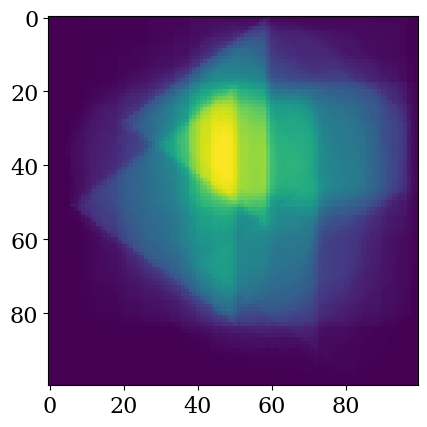

Elapsed time: 23.97 seconds


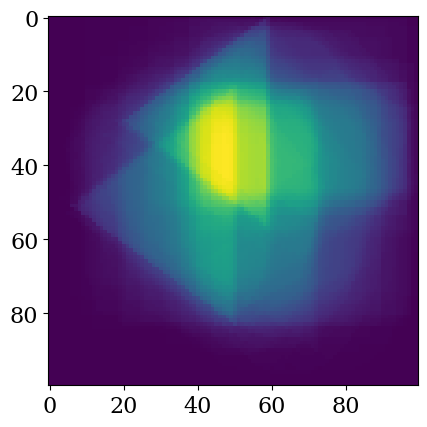

Elapsed time: 24.11 seconds


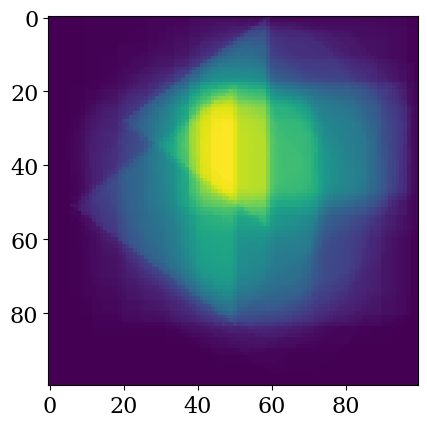

Elapsed time: 23.96 seconds


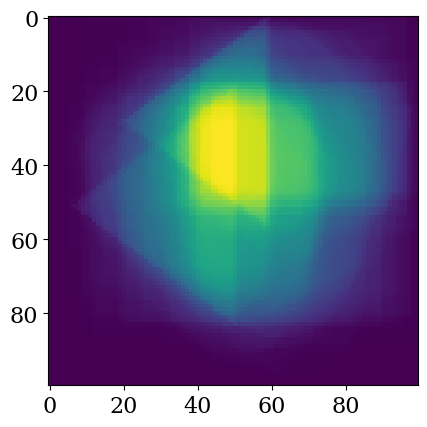

Elapsed time: 24.49 seconds


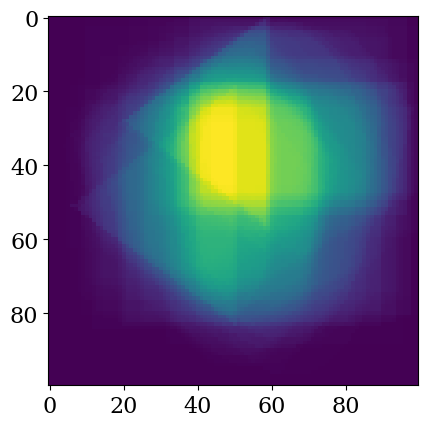

Elapsed time: 24.26 seconds


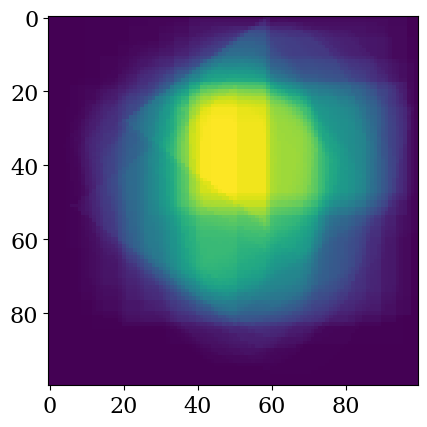

Elapsed time: 24.01 seconds


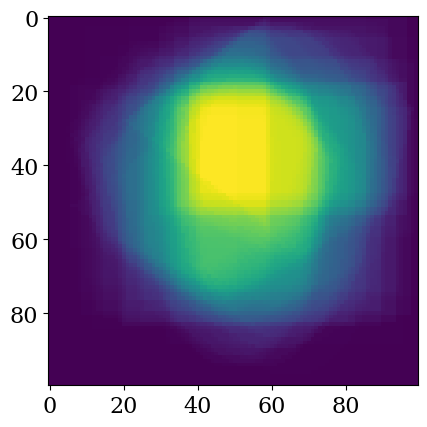

Elapsed time: 24.13 seconds


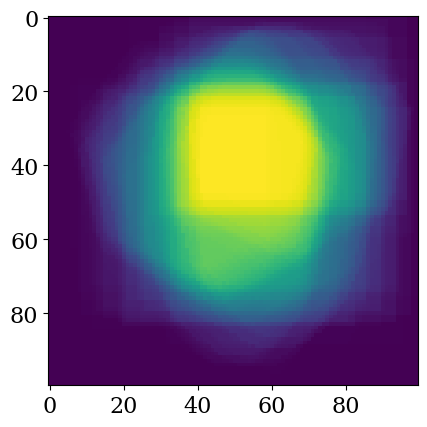

Elapsed time: 24.27 seconds


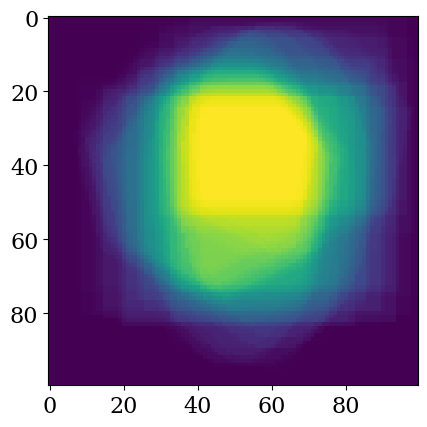

Elapsed time: 24.02 seconds


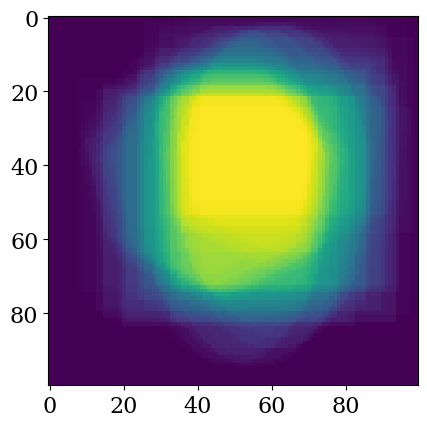

Elapsed time: 24.12 seconds


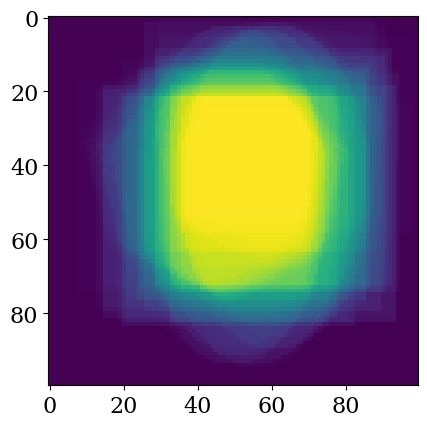

Elapsed time: 24.02 seconds


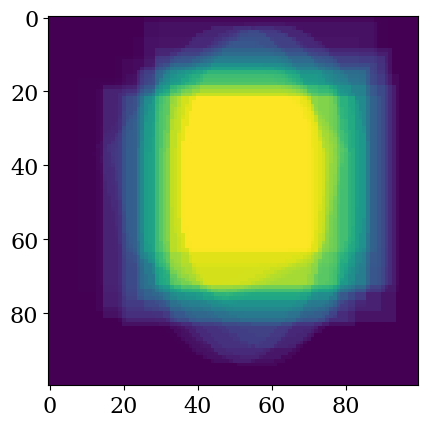

Elapsed time: 23.85 seconds


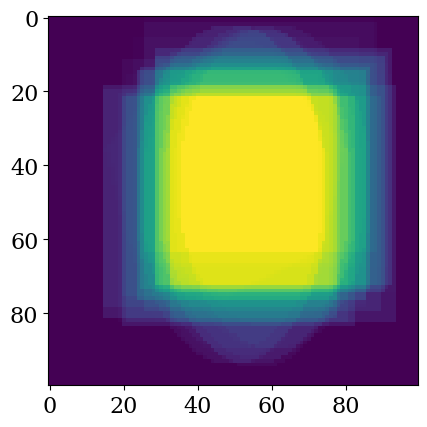

Elapsed time: 14.42 seconds


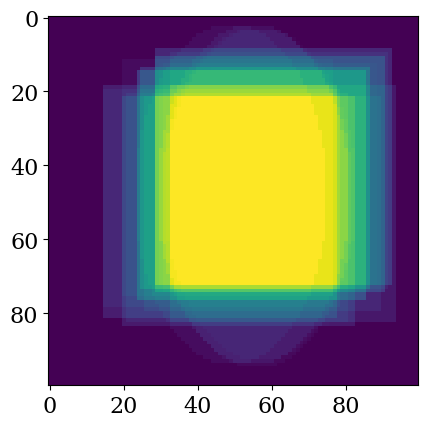

Elapsed time: 6.93 seconds


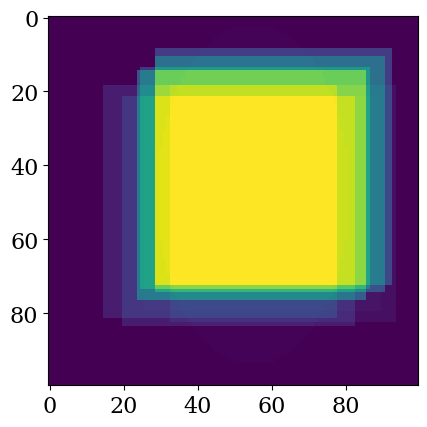

In [22]:
screening_dict['mode'] = 3
screening_dict['n_bins'] = n_bins

for lmb in lmb_vec:

  time_proc = np.zeros(num_loops, dtype=int)

  for k in range(num_loops):
    t_start = datetime.now()
    u_opt, idx_set, meas, fun_costs = optimizer.apg_opt(y, X, lmb, u_0, params_dict, functions_dict, screening_dict, alphas_dict)
    t_end = datetime.now()
    time_delta = t_end - t_start
    time_proc[k] = time_delta.seconds*1e+6 + time_delta.microseconds

  time_min  = np.min(time_proc)*1e-6
  time_mean = np.mean(time_proc)*1e-6
  time_max  = np.max(time_proc)*1e-6

  time_min_vec.append(time_min)
  time_mean_vec.append(time_mean)
  time_max_vec.append(time_max)

  print("Elapsed time:", "%.2f" % time_mean, "seconds")

  supp_mat.append(idx_set)
  card_vec.append(len(idx_set)/u_0.shape[0])

  y_pred = np.matmul(X, u_opt)
  psnr_val = util.compute_psnr(y_pred, y_teo)
  psnr_vec.append(psnr_val)

# Proposed: Adaptive thresholding

In [23]:
screening_dict['thresholding'] = 1

Elapsed time: 21.70 seconds


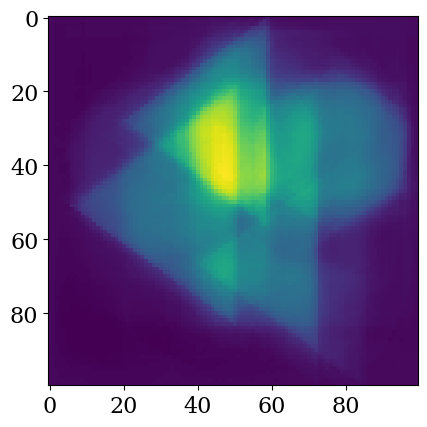

Elapsed time: 21.77 seconds


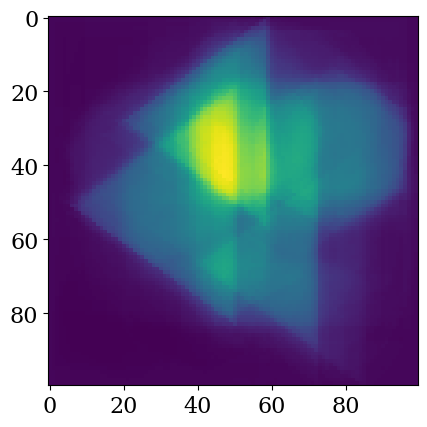

Elapsed time: 21.85 seconds


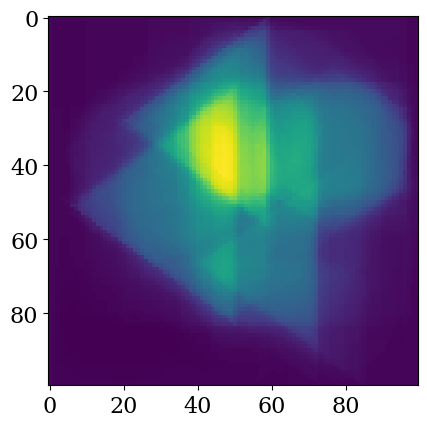

Elapsed time: 21.76 seconds


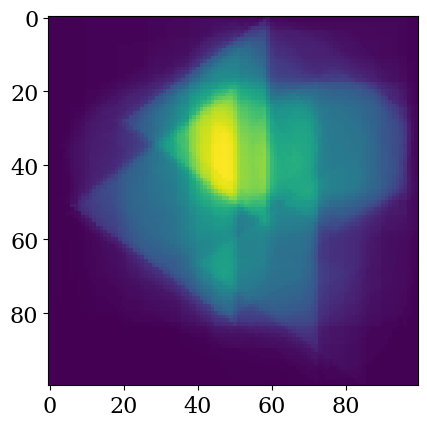

Elapsed time: 21.65 seconds


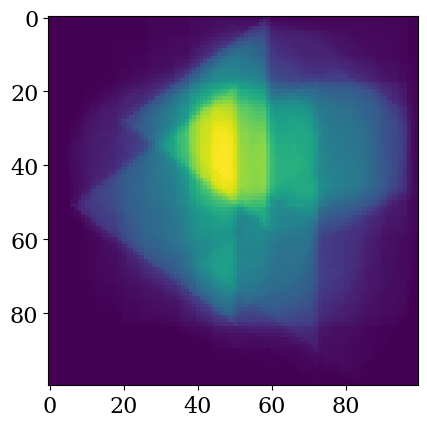

Elapsed time: 21.53 seconds


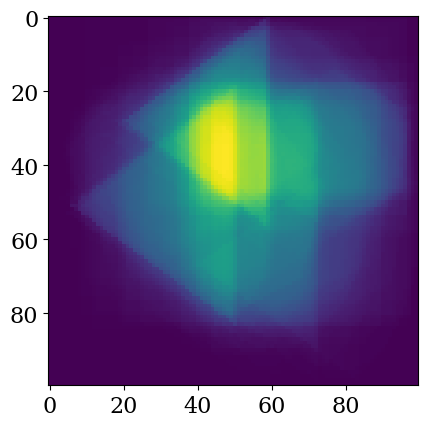

Elapsed time: 21.66 seconds


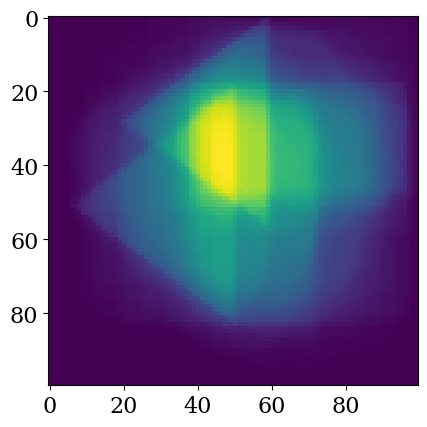

Elapsed time: 21.68 seconds


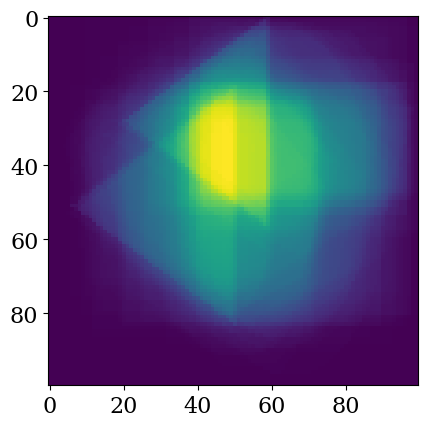

Elapsed time: 21.52 seconds


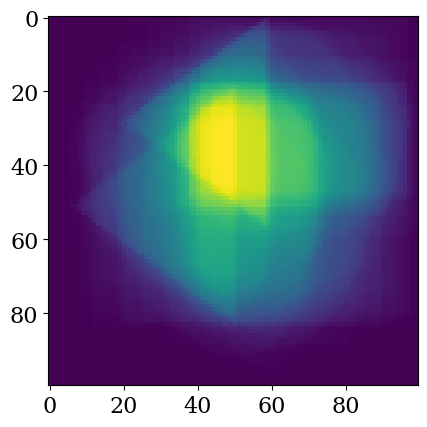

Elapsed time: 21.49 seconds


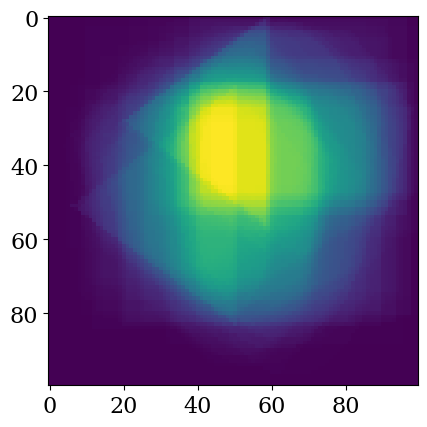

Elapsed time: 19.76 seconds


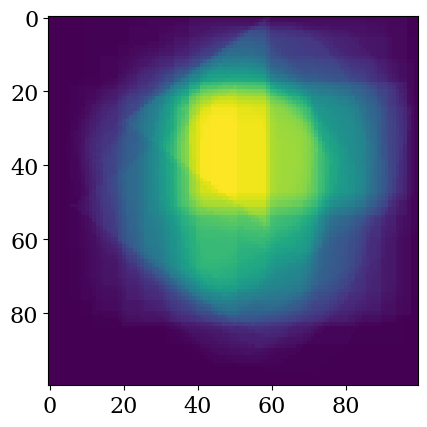

Elapsed time: 19.42 seconds


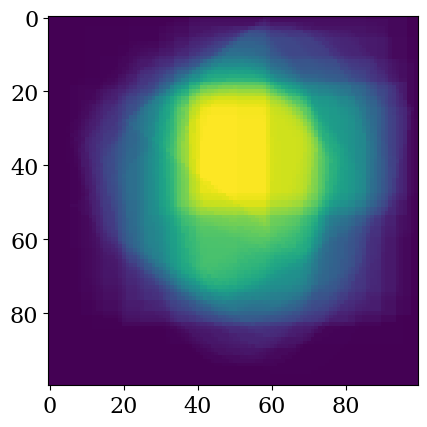

Elapsed time: 19.60 seconds


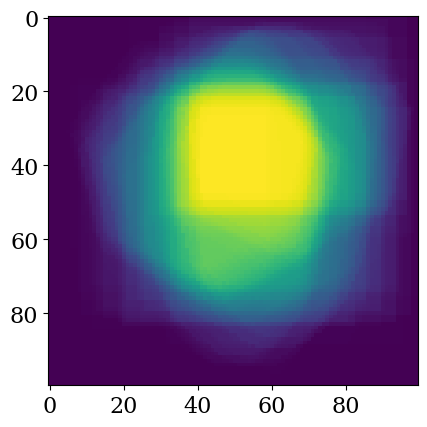

Elapsed time: 19.27 seconds


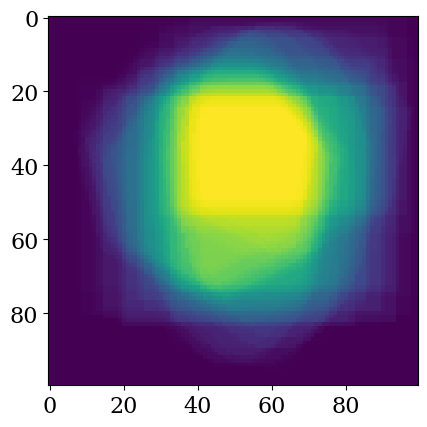

Elapsed time: 18.81 seconds


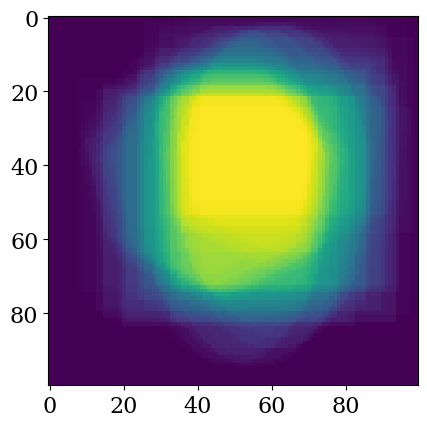

Elapsed time: 13.11 seconds


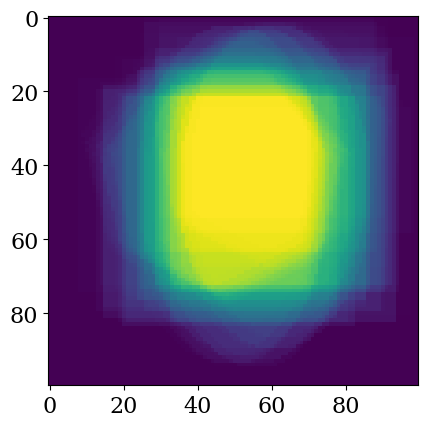

Elapsed time: 17.54 seconds


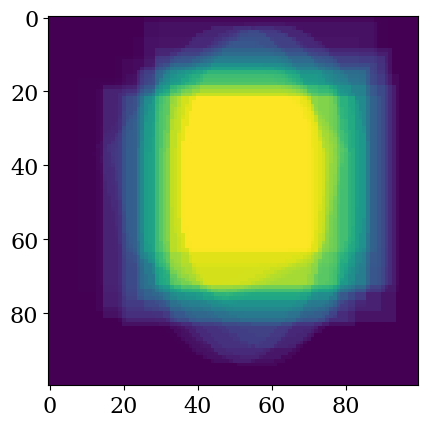

Elapsed time: 16.20 seconds


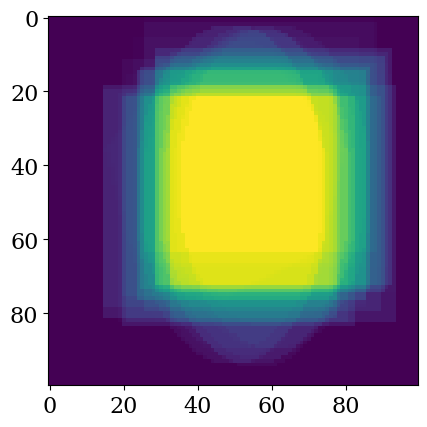

Elapsed time: 8.05 seconds


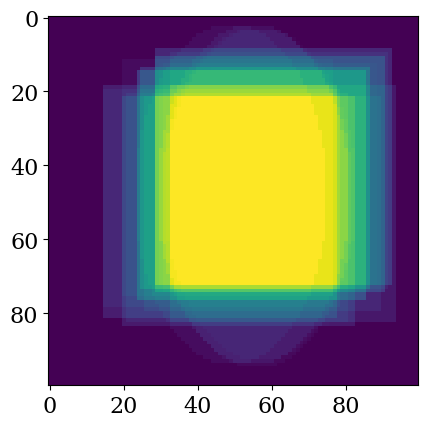

Elapsed time: 5.82 seconds


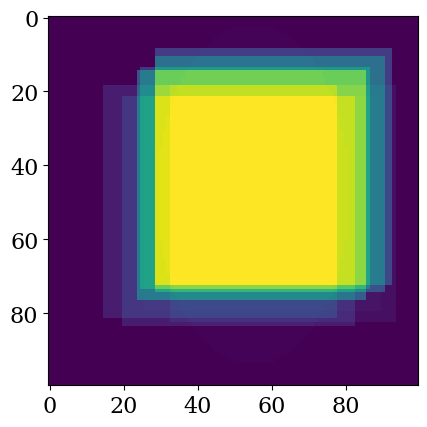

In [24]:
screening_dict['mode'] = 0
screening_dict['n_bins'] = n_bins

for lmb in lmb_vec:

  time_proc = np.zeros(num_loops, dtype=int)

  for k in range(num_loops):
    t_start = datetime.now()
    u_opt, idx_set, meas, fun_costs = optimizer.apg_opt(y, X, lmb, u_0, params_dict, functions_dict, screening_dict, alphas_dict)
    t_end = datetime.now()
    time_delta = t_end - t_start
    time_proc[k] = time_delta.seconds*1e+6 + time_delta.microseconds

  time_min  = np.min(time_proc)*1e-6
  time_mean = np.mean(time_proc)*1e-6
  time_max  = np.max(time_proc)*1e-6

  time_min_vec.append(time_min)
  time_mean_vec.append(time_mean)
  time_max_vec.append(time_max)

  print("Elapsed time:", "%.2f" % time_mean, "seconds")

  supp_mat.append(idx_set)
  card_vec.append(len(idx_set)/u_0.shape[0])

  y_pred = np.matmul(X, u_opt)
  psnr_val = util.compute_psnr(y_pred, y_teo)

  psnr_vec.append(psnr_val)

# Results

In [25]:
os.makedirs("../results", exist_ok=True)

time_mat = np.reshape(time_mean_vec, [4,lmb_vec.shape[0]])
card_mat = np.reshape(card_vec, [4,lmb_vec.shape[0]])

red_gsafe_vec = card_mat[1,:] < 1
red_strong_vec = card_mat[2,:] < 1

psnr_mat = np.reshape(psnr_vec, [4,lmb_vec.shape[0]])

## Cardinality

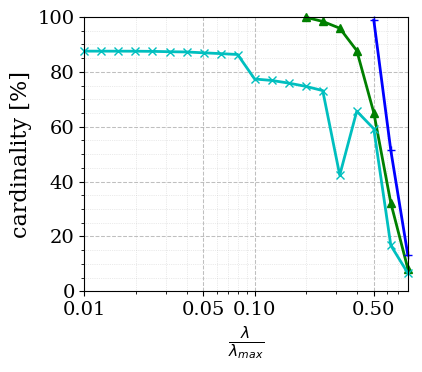

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


In [32]:
y_lim = (0,100)
x_lim = (np.min(lmb_r),np.max(lmb_r))

fig, ax = plt.subplots(figsize=(4.5,4))

plt.semilogx(lmb_r[red_gsafe_vec], 100*card_mat[1,red_gsafe_vec], color='g', label='static-gapsafe', marker='^', linewidth=2, clip_on=False)
plt.semilogx(lmb_r[red_strong_vec], 100*card_mat[2,red_strong_vec], color='b', label='static-strong', marker='+', linewidth=2, clip_on=False)
plt.semilogx(lmb_r, 100*card_mat[3,:], color='c', label='proposed', marker='x', linewidth=2, clip_on=False)

plt.grid(which='major', linestyle='--', linewidth=0.75, alpha=0.8)
plt.grid(which='minor', linestyle=':', linewidth=0.5, alpha=0.5)
plt.minorticks_on()

ax = plt.gca()

ax.xaxis.set_major_locator(FixedLocator(x_ticks))
ax.xaxis.set_major_formatter(ScalarFormatter())
ax.xaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2,10)*0.1, numticks=10))

plt.xlim(x_lim)
plt.ylim(y_lim)

plt.legend(fancybox=True, shadow=True)
plt.xlabel(r"$\frac{\lambda}{\lambda_{max}}$")
plt.ylabel("cardinality [%]")

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.tight_layout()
plt.show()

fig.savefig('../results/bpdn-cardinality.eps', format='eps', bbox_inches='tight')

## Processing time

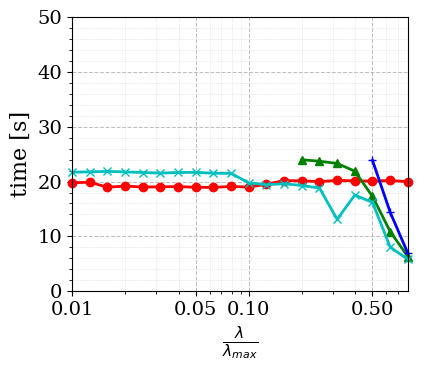

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


In [31]:
y_lim = (0,50)
x_lim = (np.min(lmb_r),np.max(lmb_r))

fig, ax = plt.subplots(figsize=(4.5,4))

plt.semilogx(lmb_r, time_mat[0,:], color='r', label='vanilla', marker='o', linewidth=2, clip_on=False)
plt.semilogx(lmb_r[red_gsafe_vec], time_mat[1,red_gsafe_vec], color='g', label='static-gapsafe', marker='^', linewidth=2, clip_on=False)
plt.semilogx(lmb_r[red_strong_vec], time_mat[2,red_strong_vec], color='b', label='static-strong', marker='+', linewidth=2, clip_on=False)
plt.semilogx(lmb_r, time_mat[3,:], color='c', label='proposed', marker='x', linewidth=2, clip_on=False)

plt.grid(which='major', linestyle='--', linewidth=0.75, alpha=0.8)
plt.grid(which='minor', linestyle=':', linewidth=0.5, alpha=0.5)
plt.minorticks_on()

ax = plt.gca()

ax.xaxis.set_major_locator(FixedLocator(x_ticks))
ax.xaxis.set_major_formatter(ScalarFormatter())
ax.xaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2,10)*0.1, numticks=10))

plt.xlim(x_lim)
plt.ylim(y_lim)

plt.legend(fancybox=True, shadow=True)
plt.xlabel(r"$\frac{\lambda}{\lambda_{max}}$")
plt.ylabel("time [s]")

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.tight_layout()
plt.show()

fig.savefig('../results/bpdn-time.eps', format='eps', bbox_inches='tight')

## Speedup

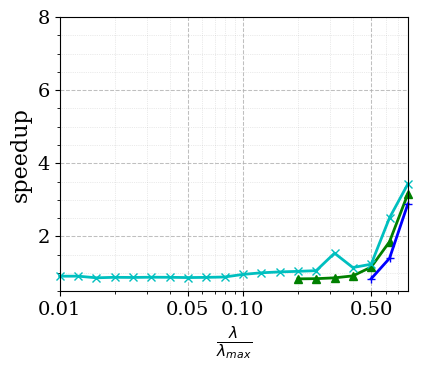

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


In [30]:
y_lim = (0.5,8)
x_lim = (np.min(lmb_r),np.max(lmb_r))

fig, ax = plt.subplots(figsize=(4.5,4))

plt.semilogx(lmb_r[red_gsafe_vec], (time_mat[0,red_gsafe_vec]/time_mat[1,red_gsafe_vec]), color='g', label='static-gapsafe', marker='^', linewidth=2, clip_on=False)
plt.semilogx(lmb_r[red_strong_vec], (time_mat[0,red_strong_vec]/time_mat[2,red_strong_vec]), color='b', label='static-strong', marker='+', linewidth=2, clip_on=False)
plt.semilogx(lmb_r, (time_mat[0,:]/time_mat[3,:]), color='c', label='proposed', marker='x', linewidth=2, clip_on=False)

plt.grid(which='major', linestyle='--', linewidth=0.75, alpha=0.8)
plt.grid(which='minor', linestyle=':', linewidth=0.5, alpha=0.5)
plt.minorticks_on()

ax = plt.gca()

ax.xaxis.set_major_locator(FixedLocator(x_ticks))
ax.xaxis.set_major_formatter(ScalarFormatter())
ax.xaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2,10)*0.1, numticks=10))

plt.xlim(x_lim)
plt.ylim(y_lim)

plt.legend(fancybox=True, shadow=True)
plt.xlabel(r"$\frac{\lambda}{\lambda_{max}}$")
plt.ylabel("speedup")

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.tight_layout()
plt.show()

fig.savefig('../results/bpdn-speedup.eps', format='eps', bbox_inches='tight')

## PSNR

/tmp/ipykernel_96034/1114229634.py:24: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


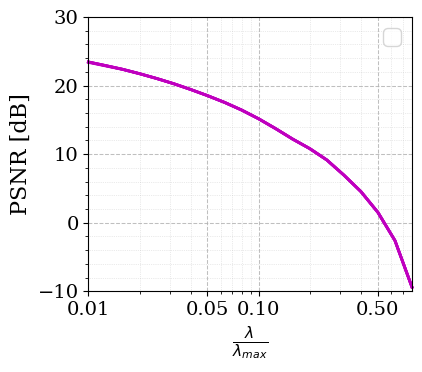

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


In [29]:
y_lim = (-10,30)
x_lim = (np.min(lmb_r),np.max(lmb_r))

fig, ax = plt.subplots(figsize=(4.5,4))

plt.semilogx(lmb_r, psnr_mat[0,:], color='m', linewidth=2, clip_on=False)
plt.semilogx(lmb_r, psnr_mat[1,:], color='m', linewidth=2, clip_on=False)
plt.semilogx(lmb_r, psnr_mat[2,:], color='m', linewidth=2, clip_on=False)
plt.semilogx(lmb_r, psnr_mat[3,:], color='m', linewidth=2, clip_on=False)

plt.grid(which='major', linestyle='--', linewidth=0.75, alpha=0.8)
plt.grid(which='minor', linestyle=':', linewidth=0.5, alpha=0.5)
plt.minorticks_on()

ax = plt.gca()

ax.xaxis.set_major_locator(FixedLocator(x_ticks))
ax.xaxis.set_major_formatter(ScalarFormatter())
ax.xaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2,10)*0.1, numticks=10))

plt.xlim(x_lim) 
plt.ylim(y_lim)

plt.legend()
plt.xlabel(r"$\frac{\lambda}{\lambda_{max}}$")
plt.ylabel("PSNR [dB]")

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.tight_layout()
plt.show()

fig.savefig('bpdn-psnr.eps', format='eps', bbox_inches='tight')